## What is NetworkX?

**NetworkX** is a Python library for creating, analyzing, and visualizing networks (graphs). It's particularly useful for historians working with **relational data** — meaning data about *relationships between entities*, not to be confused with "relational databases."

### Terminology Note: Two Meanings of "Relational"

- **Relational database** (RDBMS like PostgreSQL): tables with foreign keys, normalized schema
- **Relational data** (network analysis): data about *connections* between entities

The good news: **join tables in a relational database are perfect for network analysis!** A many-to-many join table (e.g., `person_helped_person`, `author_cited_author`, `organization_membership`) represents exactly what a network edge list needs: source → target relationships.

### Loading Data from PostgreSQL

If your data is in PostgreSQL, you can easily pull it into NetworkX:

```python
import psycopg2
import pandas as pd

# connect to database
conn = psycopg2.connect("dbname=mydb user=myuser")

# query a join table (this is your edge list!)
relations = pd.read_sql("SELECT giver, recipient, form_of_help FROM help_network", conn)

# query entity attributes (this is your node list)
people = pd.read_sql("SELECT name, status, gender FROM people", conn)

# now build the graph as shown below
```

Any table with two entity columns and optional attribute columns can become a network.

### Common NetworkX Functions

**Graph Creation:**
- `nx.Graph()` — create an undirected graph
- `nx.DiGraph()` — create a directed graph (relationships have direction)
- `G.add_node(name, **attributes)` — add a node with optional attributes
- `G.add_edge(source, target, **attributes)` — add an edge (relationship)

**Graph Metrics:**
- `nx.density(G)` — proportion of possible edges that exist
- `nx.degree_centrality(G)` — how connected each node is
- `nx.betweenness_centrality(G)` — identifies brokers between groups
- `nx.closeness_centrality(G)` — how quickly a node can reach others
- `G.in_degree()` / `G.out_degree()` — for directed graphs only

**Analysis:**
- `nx.shortest_path(G, source, target)` — find path between two nodes
- `nx.is_weakly_connected(G)` — check if graph is connected
- `nx.connected_components(G)` — find separate clusters

**Visualization:**
- `nx.draw_networkx()` — basic visualization with matplotlib
- `nx.spring_layout(G)` — force-directed layout algorithm
- `nx.write_graphml(G, filename)` — export for use in Gephi or other tools

📚 Full documentation: [https://networkx.org/](https://networkx.org/)

In [1]:
# Import Required Libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# configure inline plotting for notebooks
%matplotlib inline

## Setup Instructions

Before running this notebook, make sure the required packages are installed.

```bash
pip install pandas networkx matplotlib
```

(If you are on macOS, use `python3 -m pip` or `pip3` and consider working
inside a virtual environment.)

# NetworkX Example with Neumann Dataset

This notebook walks through a simple network analysis using **NetworkX** and the
CSV files from the Programming Historian tutorial. We'll load the relations and
attributes tables, build a directed graph, compute metrics, filter edges, and
visualize a few views.

In [2]:
## Load Data

# assuming CSVs in instruction/week-08
relations = pd.read_csv("network-example1-en.csv")
attributes = pd.read_csv("network-example2-en.csv")

# quick look
relations.head(), attributes.head()

(                   Giver      Recipient  Form of Help  Relation  \
 0      MitgliedOnkelEmil   Rita Neumann             3         2   
 1            Leo Fraines  Ralph Neumann             4         6   
 2           Walter Seitz   Ruth Hohmann             2         4   
 3            Leo Fraines  Ralph Neumann             8         4   
 4  SchwarzmarktVermieter  Ralph Neumann            18         2   
 
    Date of Activity  Date of first Meeting  Time Step Start  Time step End  
 0                15                     15               15             16  
 1                12                      9               12             13  
 2                15                     15               15             16  
 3                10                      9               10             11  
 4                10                     10               10             11  ,
              Person  NS Race Status  Gender
 0  Ludwig Lichtwitz              99      99
 1     Ralph Neumann           

### Alternative: Loading from PostgreSQL

If your data is in a PostgreSQL database (or any RDBMS), you can load it directly:

```python
import psycopg2

# connect to your database
conn = psycopg2.connect(
    host="localhost",
    database="hist_research",
    user="historian",
    password="your_password"
)

# load edge list from a join table
relations = pd.read_sql("""
    SELECT giver_id, recipient_id, form_of_help, date_of_activity
    FROM help_network
    WHERE date_of_activity BETWEEN '1943-01-01' AND '1945-12-31'
""", conn)

# load node attributes from entity table
attributes = pd.read_sql("""
    SELECT person_id, name, race_status, gender
    FROM people
""", conn)

conn.close()
```

The key insight: **any many-to-many relationship table in your database is already a network edge list.** Think of:
- `author_cited_author` → citation network
- `person_attended_event` → bipartite network (people × events)
- `organization_membership` → affiliation network
- `manuscript_mentions_person` → bipartite network (documents × people)

In [3]:
## Create NetworkX Graph

# build directed graph
G = nx.DiGraph()

# add nodes with attributes
for _, row in attributes.iterrows():
    G.add_node(row['Person'], **row.drop('Person').to_dict())

# add edges with attributes
for _, row in relations.iterrows():
    G.add_edge(row['Giver'], row['Recipient'], **row.drop(['Giver','Recipient']).to_dict())

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph has 41 nodes and 71 edges


## Basic Network Information

Let's examine some basic properties of the network.

In [4]:
# density: what proportion of all possible edges are present?
density = nx.density(G)

# is it connected? (ignoring directionality)
weakly_connected = nx.is_weakly_connected(G)

# how many connected components?
num_components = nx.number_weakly_connected_components(G)

print(f"Density: {density:.3f}")
print(f"Weakly connected: {weakly_connected}")
print(f"Number of weakly connected components: {num_components}")

Density: 0.043
Weakly connected: False
Number of weakly connected components: 2


## Compute Centrality Metrics

**Centrality** measures help us identify the most "important" nodes according to different criteria:

- **Degree centrality**: How many connections does a node have?
- **In-degree / Out-degree**: For directed graphs, how many edges come in vs. go out?
- **Betweenness centrality**: How often does a node sit on the shortest path between others? (identifies brokers)
- **Closeness centrality**: How quickly can a node reach all others?

In [5]:
# compute degree centrality (total connections)
degree_centrality = nx.degree_centrality(G)

# in-degree and out-degree (for directed graphs)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# betweenness centrality (identifies brokers)
betweenness = nx.betweenness_centrality(G)

# sort and show top 5 by betweenness (most important brokers)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by Betweenness Centrality (brokers):")
for node, score in top_betweenness:
    print(f"  {node}: {score:.3f} (in-degree={in_degree[node]}, out-degree={out_degree[node]})")

Top 5 nodes by Betweenness Centrality (brokers):
  Ralph Neumann: 0.144 (in-degree=26, out-degree=2)
  Agnes Wendland: 0.136 (in-degree=3, out-degree=7)
  Rita Neumann: 0.077 (in-degree=17, out-degree=3)
  Harald Poelchau: 0.030 (in-degree=1, out-degree=3)
  Sohn Wendland: 0.022 (in-degree=1, out-degree=1)


## Visualize the Full Network

NetworkX uses matplotlib for basic visualizations. The layout algorithm tries to optimize legibility, so **spatial distance is not literal** — read only the connections themselves, not the physical distance between nodes.

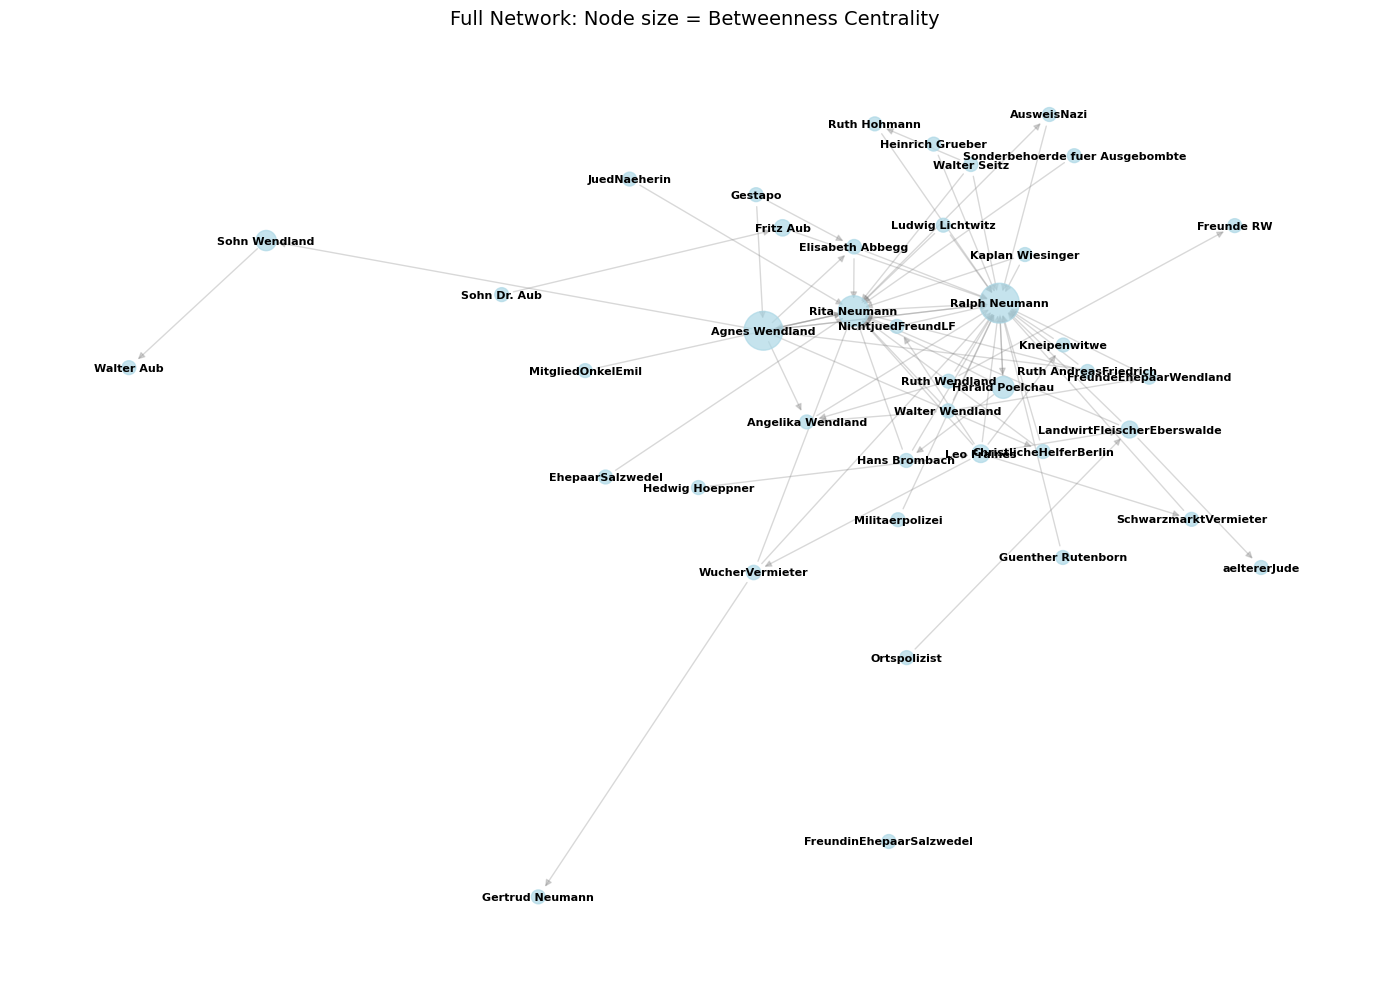

In [6]:
plt.figure(figsize=(14, 10))

# use spring layout for a force-directed graph
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# draw nodes sized by betweenness centrality
node_sizes = [betweenness[node] * 5000 + 100 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Full Network: Node size = Betweenness Centrality", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Filter by Edge Attribute

The edges in this graph have attributes like **Form of Help**. Let's filter the network to show only one kind of relationship. Looking at the data, Form of Help = 3 represents "Accommodation."

In [7]:
# filter edges where Form of Help == 3 (Accommodation)
accommodation_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('Form of Help') == 3]

# create subgraph with only those edges
G_accommodation = G.edge_subgraph(accommodation_edges).copy()

print(f"Accommodation subgraph: {G_accommodation.number_of_nodes()} nodes, {G_accommodation.number_of_edges()} edges")

Accommodation subgraph: 18 nodes, 18 edges


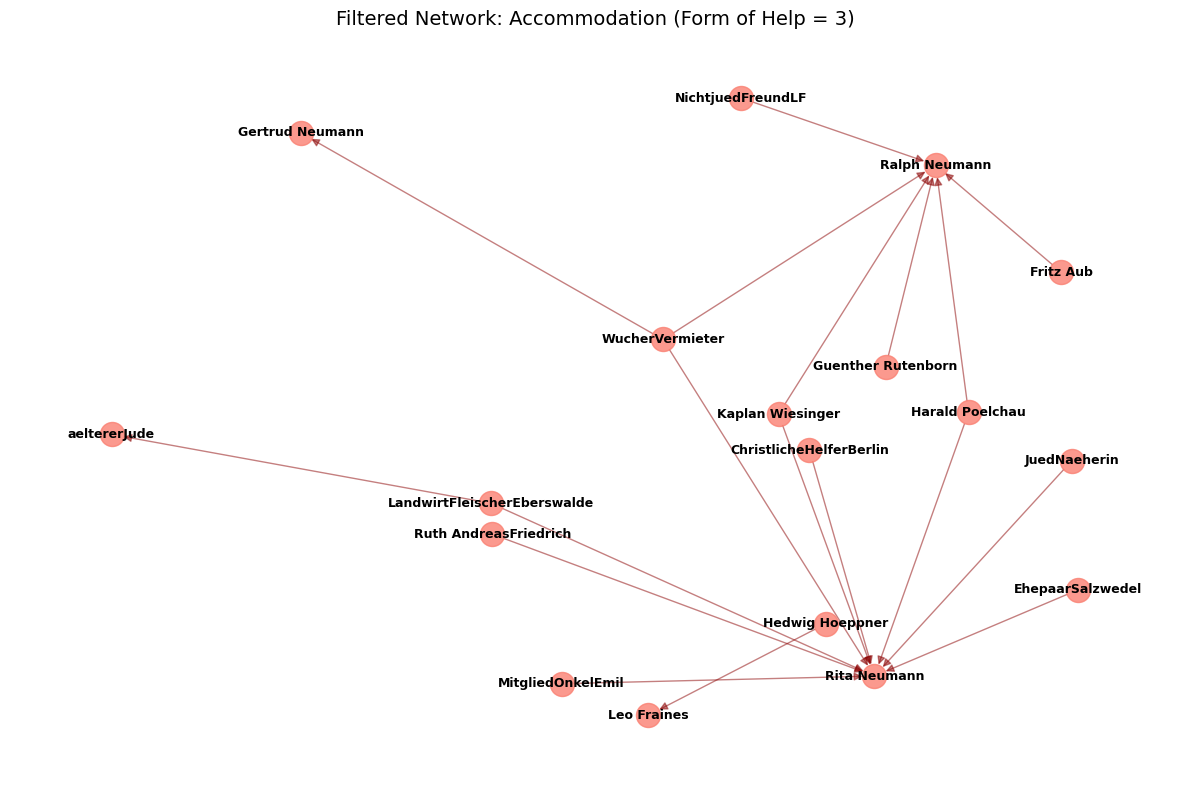

In [8]:
plt.figure(figsize=(12, 8))

# use same layout for comparison
pos_sub = nx.spring_layout(G_accommodation, k=0.8, iterations=50, seed=42)

nx.draw_networkx_nodes(G_accommodation, pos_sub, node_size=300, node_color='salmon', alpha=0.8)
nx.draw_networkx_edges(G_accommodation, pos_sub, alpha=0.5, arrows=True, arrowsize=12, edge_color='darkred')
nx.draw_networkx_labels(G_accommodation, pos_sub, font_size=9, font_weight='bold')

plt.title("Filtered Network: Accommodation (Form of Help = 3)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Analyze Directionality: Givers vs. Recipients

Since this is a directed network representing *help given*, we can identify:
- **Pure givers**: out-degree > 0, in-degree = 0
- **Pure recipients**: in-degree > 0, out-degree = 0  
- **Both**: in-degree > 0 AND out-degree > 0

In [9]:
pure_givers = [node for node in G.nodes() if out_degree[node] > 0 and in_degree[node] == 0]
pure_recipients = [node for node in G.nodes() if in_degree[node] > 0 and out_degree[node] == 0]
both = [node for node in G.nodes() if in_degree[node] > 0 and out_degree[node] > 0]

print(f"Pure givers (only gave help): {len(pure_givers)}")
print(f"  Examples: {pure_givers[:5]}")
print(f"\nPure recipients (only received help): {len(pure_recipients)}")
print(f"  Examples: {pure_recipients[:5]}")
print(f"\nBoth givers and recipients: {len(both)}")
print(f"  Examples: {both[:5]}")

Pure givers (only gave help): 17
  Examples: ['Ludwig Lichtwitz', 'JuedNaeherin', 'Hedwig Hoeppner', 'EhepaarSalzwedel', 'Ortspolizist']

Pure recipients (only received help): 4
  Examples: ['Freunde RW', 'aeltererJude', 'Walter Aub', 'Gertrud Neumann']

Both givers and recipients: 19
  Examples: ['Ralph Neumann', 'Rita Neumann', 'Leo Fraines', 'SchwarzmarktVermieter', 'Kneipenwitwe']


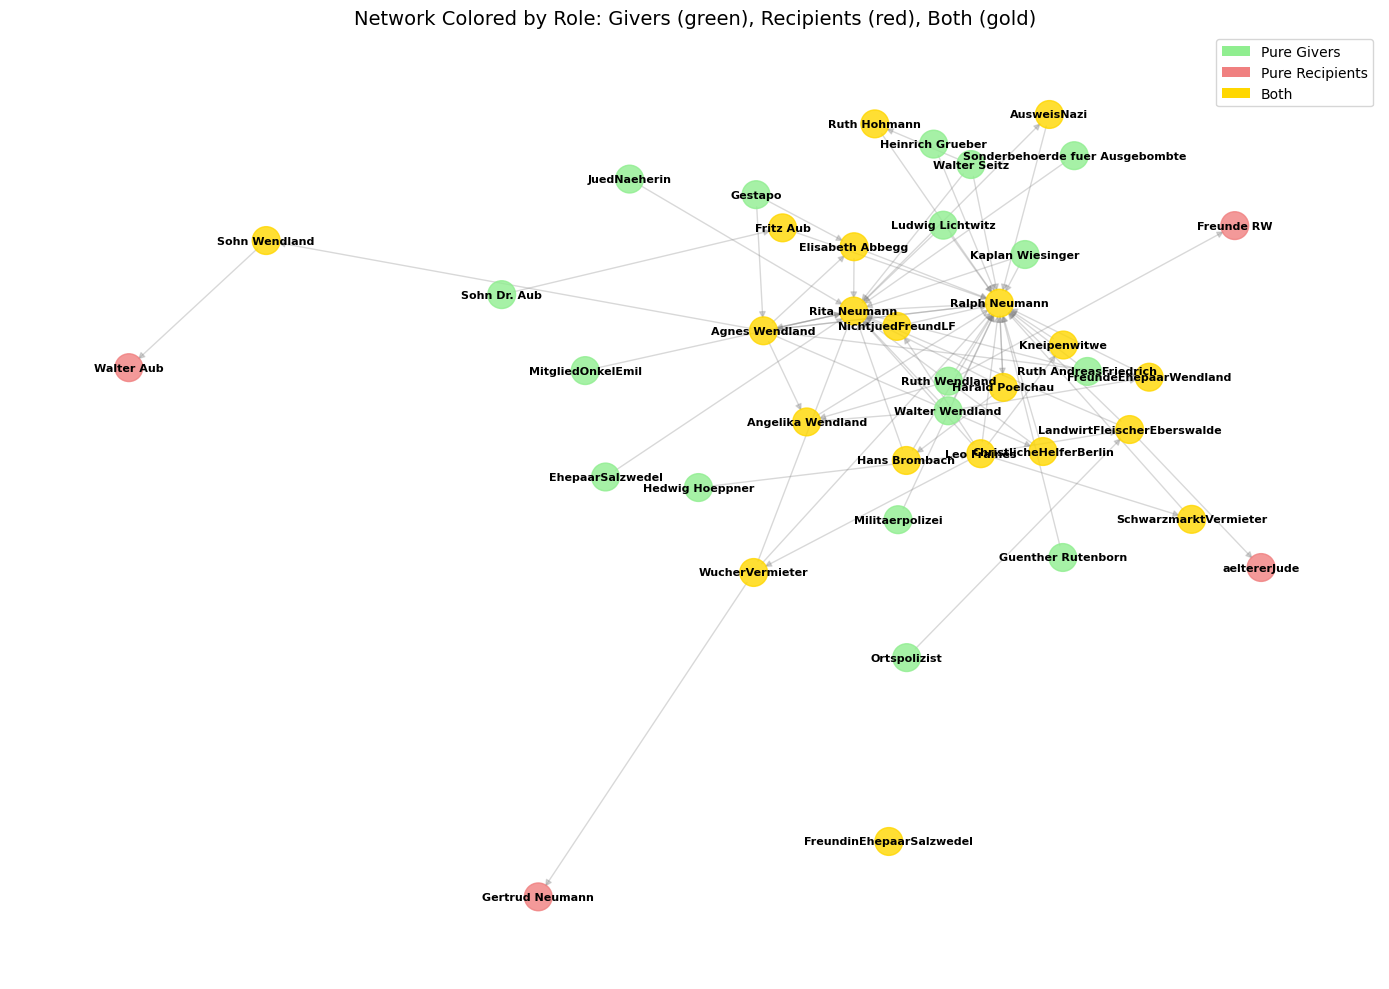

In [10]:
# visualize with color-coding by role
plt.figure(figsize=(14, 10))

# assign colors based on role
node_colors = []
for node in G.nodes():
    if node in pure_givers:
        node_colors.append('lightgreen')
    elif node in pure_recipients:
        node_colors.append('lightcoral')
    else:
        node_colors.append('gold')

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', label='Pure Givers'),
    Patch(facecolor='lightcoral', label='Pure Recipients'),
    Patch(facecolor='gold', label='Both')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.title("Network Colored by Role: Givers (green), Recipients (red), Both (gold)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## Bipartite Network: People × Time Period

A **bipartite network** has two different types of nodes. Instead of connecting people to people, we can connect people to *time periods* in which they were active. This reveals temporal patterns: who was present at the same time?

In [11]:
# create bipartite graph: people connected to time steps
B = nx.Graph()

# add people nodes and time step nodes
for _, row in relations.iterrows():
    giver = row['Giver']
    recipient = row['Recipient']
    time_step = f"Time_{row['Time Step Start']}"
    
    # add edges from people to time periods
    B.add_node(giver, bipartite=0)  # people
    B.add_node(recipient, bipartite=0)
    B.add_node(time_step, bipartite=1)  # time periods
    
    B.add_edge(giver, time_step)
    B.add_edge(recipient, time_step)

# separate the two node sets
people_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
time_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 1}

print(f"Bipartite graph: {len(people_nodes)} people, {len(time_nodes)} time periods")

Bipartite graph: 40 people, 5 time periods


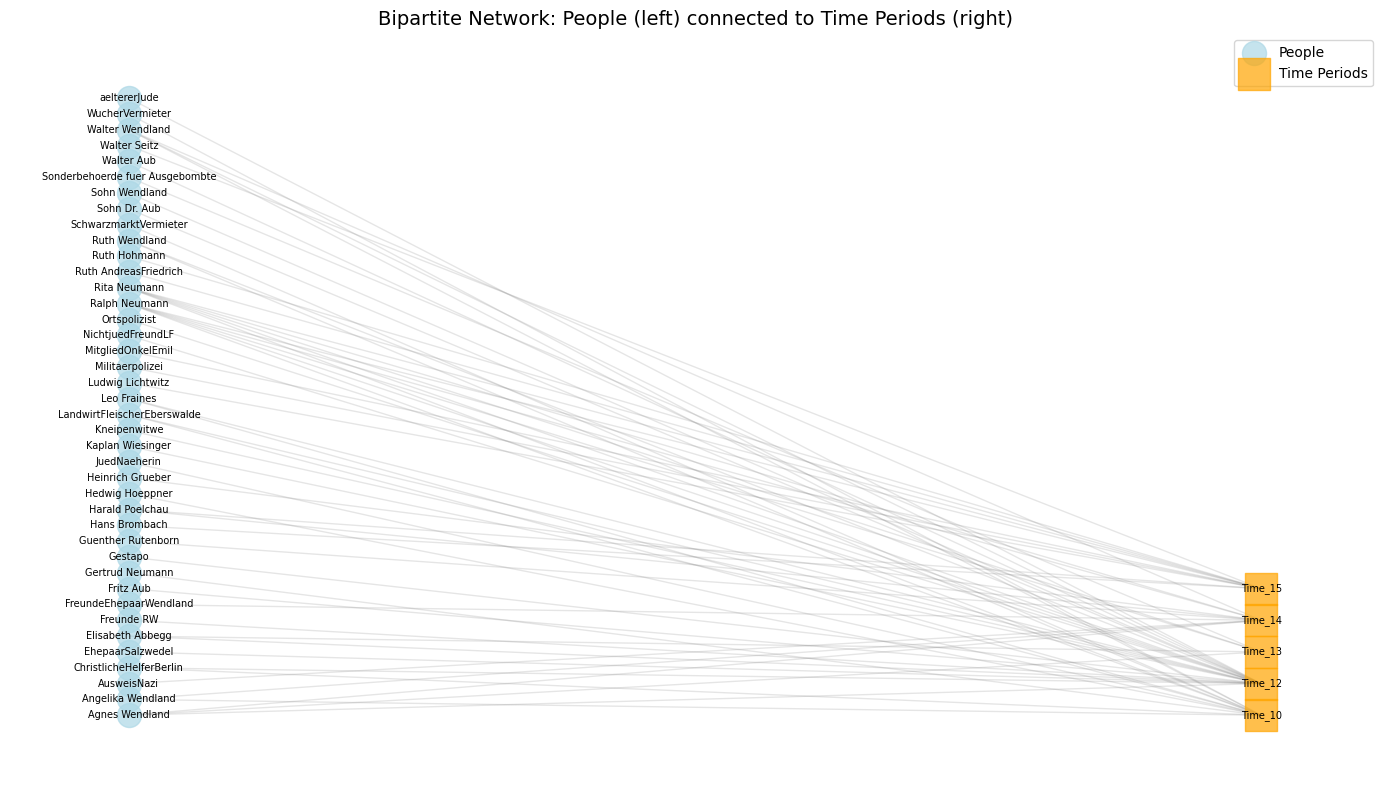

In [12]:
# visualize bipartite network
from networkx.algorithms import bipartite

plt.figure(figsize=(14, 8))

# use bipartite layout: people on left, time on right
pos_bipartite = {}
people_list = sorted(people_nodes)
time_list = sorted(time_nodes)

for i, node in enumerate(people_list):
    pos_bipartite[node] = (0, i * 2)
for i, node in enumerate(time_list):
    pos_bipartite[node] = (3, i * 4)

nx.draw_networkx_nodes(B, pos_bipartite, nodelist=people_nodes, node_color='lightblue', 
                       node_size=300, alpha=0.7, label='People')
nx.draw_networkx_nodes(B, pos_bipartite, nodelist=time_nodes, node_color='orange', 
                       node_size=500, alpha=0.7, label='Time Periods', node_shape='s')
nx.draw_networkx_edges(B, pos_bipartite, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(B, pos_bipartite, font_size=7)

plt.title("Bipartite Network: People (left) connected to Time Periods (right)", fontsize=14)
plt.legend(loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()

## Critical Interpretation

### Key Concepts to Remember:

1. **Spatial distance in the visualization is NOT literal**  
   Layout algorithms optimize for legibility. A node that appears far away may just have been placed there so its label doesn't overlap with others. Read only the *connections* (edges), not the physical distance.

2. **Visualizations are prompts, not proofs**  
   As Marten Düring writes: "Visualizations are not 'proof' of anything but tools to help understand complex relations." The graph should send you back to your sources with new questions.

3. **Nodes and edges are drastically simplified**  
   The coding scheme reduces complex, ambiguous historical relationships to discrete categories. Every visualization hides as much as it reveals.

4. **What you can't see matters**  
   - Relationships you coded as "unknown" (99) don't appear in the graph
   - Ambiguous cases you excluded
   - People mentioned in sources but not involved in help-giving

5. **The method's value is in the dialogue**  
   Network analysis works best when you move back and forth between the visualization and the original sources, using each to interrogate the other.

## Next Steps: Modifying and Extending the Analysis

You can extend this analysis in many ways:

- **Filter by multiple attributes**: Combine Form of Help, Date of Activity, and Relation type
- **Compute closeness centrality**: `nx.closeness_centrality(G)` to find who can reach others quickly
- **Find shortest paths**: `nx.shortest_path(G, source, target)` to trace connection chains
- **Detect communities**: Use algorithms like `nx.community.louvain_communities()` to find clusters
- **Export for Gephi**: Save as GraphML with `nx.write_graphml(G, "network.graphml")` for more advanced visualization
- **Analyze your own data**: Replace the CSV files with your own relations and attributes tables

## Interactive Visualization with Plotly

**Matplotlib** (what we've been using) creates static images. **Plotly** creates interactive visualizations where you can:
- Zoom and pan
- Hover over nodes to see details
- Click and drag nodes to rearrange the layout
- Export as HTML for sharing

First install plotly: `pip install plotly`

In [13]:
import plotly.graph_objects as go

# use the same spring layout coordinates we already computed
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)  # None creates a break between edges
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    # hover text showing node name and degree
    node_text.append(f"{node}<br>In-degree: {in_degree[node]}<br>Out-degree: {out_degree[node]}")

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        showscale=True,
        colorscale='YlOrRd',
        size=10,
        color=[betweenness[node] for node in G.nodes()],
        colorbar=dict(
            thickness=15,
            title='Betweenness'
        ),
        line_width=2))

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(text='Interactive Network: Hover over nodes for details', font=dict(size=16)),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=0,l=0,r=0,t=40),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

fig.show()

# To save as HTML: fig.write_html("network.html")

### Matplotlib vs. Plotly: When to Use Each

**Use Matplotlib when:**
- You need static images for papers/presentations
- You want fine-grained control over styling
- File size matters (matplotlib PNGs are small)
- Quick exploratory work

**Use Plotly when:**
- You're exploring a large network and need to zoom in/out
- You want to share interactive HTML files
- Hover tooltips would help identify nodes
- You're building a web dashboard
- You want to let others explore your network

Both work with the same NetworkX graph — just different ways of displaying it!

## Additional Examples and Export

Below are a couple of quick snippets demonstrating how to query the network for
specific information (shortest path between two nodes) and how to export the
graph for use in other tools such as Gephi.

In [14]:
# Example: Find shortest path between two nodes
# choose a pair likely to be connected (Leo Fraines → Ralph Neumann)
start, end = 'Leo Fraines', 'Ralph Neumann'
if start in G and end in G:
    if nx.has_path(G, start, end):
        path = nx.shortest_path(G, start, end)
        print(f"Shortest path from {start} to {end}:")
        print(" → ".join(path))
    else:
        print(f"No path exists between {start} and {end}")
else:
    print("One of the nodes not present in graph")

# Export graph to GraphML for use in Gephi or other tools
# nx.write_graphml(G, "neumann_network.graphml")
# print("\nGraph exported to neumann_network.graphml")

Shortest path from Leo Fraines to Ralph Neumann:
Leo Fraines → Ralph Neumann


## Summary

In this notebook, you've learned how to:

✅ Load network data from CSV files  
✅ Build a **directed graph** with node and edge attributes  
✅ Compute **centrality metrics** (degree, betweenness) to identify important nodes  
✅ Visualize networks with different layouts and coloring schemes  
✅ **Filter** networks by edge attributes to explore subgraphs  
✅ Analyze **directionality** (givers vs. recipients)  
✅ Create **bipartite networks** (people × time)  
✅ Apply critical interpretation to network visualizations  

**Key takeaway**: Network analysis transforms complexity from a problem into an object of research — but only when used critically, with constant attention to what the model reveals *and* what it conceals.